# Benchmark Notebook: Đo Hiệu Quả Prompting

Notebook này dùng để đo nhanh hiệu quả của hai cách prompting trên một tập con của **GSM8K**:
- **Standard prompting**: gọi model một lần với `temperature = 0`
- **Self-consistency prompting**: gọi nhiều lần với `temperature > 0`, rồi chọn đáp án ổn định hơn

Mục tiêu của bài test là xem self-consistency có cải thiện accuracy trên các bài toán toán học suy luận nhiều bước hay không.


## Bước 1. Chuẩn bị tập đánh giá

Cell bên dưới làm 3 việc:
1. tải tập `test` của bộ dữ liệu **GSM8K** từ Hugging Face,
2. lấy ngẫu nhiên `20` câu hỏi để chạy thử nhanh,
3. tiền xử lý `ground truth` bằng cách tách đáp án số cuối cùng sau dấu `####`.

Kết quả của cell này là biến `test_data`, mỗi phần tử gồm:
- `id`: số thứ tự câu hỏi
- `question`: nội dung bài toán
- `answer`: đáp án đúng đã được chuẩn hoá


In [1]:
import random
from datasets import load_dataset

# Tải bộ dữ liệu GSM8K (tập test) từ Hugging Face
print("⏳ Đang tải bộ dữ liệu GSM8K từ Hugging Face...")
dataset = load_dataset("openai/gsm8k", "main", split="test")

# Lấy ngẫu nhiên 20 mẫu
random.seed(42) # Để kết quả có thể lặp lại
raw_samples = random.sample(list(dataset), 20)

# Tiền xử lý dữ liệu: GSM8K trả về đáp án kèm lời giải sau dấu '####'
test_data = []
for i, item in enumerate(raw_samples):
    question = item['question']
    # Trích xuất con số cuối cùng sau '####' làm Ground Truth
    ground_truth = item['answer'].split('#### ')[-1].strip().replace(',', '')
    test_data.append({"id": i+1, "question": question, "answer": ground_truth})

print(f"✅ Đã chuẩn bị xong 20 mẫu test. Câu hỏi ví dụ: \n{test_data[0]['question']}")

/Users/hoainam/Desktop/Project/Codelab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Đang tải bộ dữ liệu GSM8K từ Hugging Face...


Generating test split: 100%|██████████| 1319/1319 [00:00<00:00, 555171.80 examples/s]

✅ Đã chuẩn bị xong 20 mẫu test. Câu hỏi ví dụ: 
The girls are trying to raise money for a carnival. Kim raises $320 more than Alexandra, who raises $430, and Maryam raises $400 more than Sarah, who raises $300. How much money, in dollars, did they all raise in total?


## Bước 2. Chạy benchmark và so sánh

Cell bên dưới là phần đo hiệu quả chính của notebook. Với mỗi câu hỏi trong `test_data`, nó sẽ:
1. chạy **Standard prompting** một lần để lấy đáp án baseline,
2. chạy **Self-consistency** với `k = 3` đường suy luận,
3. embed các câu trả lời self-consistency và tính **cosine similarity**,
4. chọn response ổn định nhất làm đáp án cuối cùng của nhánh self-consistency,
5. so sánh cả hai đáp án với `ground truth`,
6. ghi toàn bộ kết quả ra file CSV và in accuracy tổng kết.

Nói ngắn gọn: đây là cell thực nghiệm để trả lời câu hỏi **self-consistency có giúp model làm GSM8K tốt hơn baseline hay không**.


In [2]:
import csv
import re
import numpy as np
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity

client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

def extract_number(text):
    """Trích xuất con số cuối cùng từ văn bản trả về của mô hình"""
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", text.replace(',', ''))
    return numbers[-1] if numbers else None

results = []
print(f"🚀 Bắt đầu đo hiệu quả trên Mac M2 (k=3 paths)...")

for item in test_data:
    q_id = item['id']
    question = item['question']
    gt = item['answer']

    # 1. STANDARD PROMPTING (Temperature = 0 để đạt tính ổn định nhất [cite: 1547])
    try:
        std_output = client.chat.completions.create(
            model="gemma4",
            messages=[{"role": "user", "content": f"{question}\nTrả về đáp án là 1 con số duy nhất."}],
            temperature=0
        ).choices[0].message.content.strip()
        std_ans = extract_number(std_output)
    except: std_ans = None

    # 2. SELF-CONSISTENCY (3 luồng, Temperature = 0.8 để tạo sự đa dạng [cite: 1781])
    sc_responses = []
    for _ in range(3):
        try:
            res = client.chat.completions.create(
                model="gemma4",
                messages=[{"role": "user", "content": f"{question}\nLet's think step by step[cite: 1742]. Trả về đáp án cuối cùng ở dòng cuối dạng: Answer: [số]."}],
                temperature=0.8
            ).choices[0].message.content.strip()
            sc_responses.append(res)
        except: continue

    # Tính Similarity và Majority Vote bằng Embedding
    sc_final_ans = None
    consistency_score = 0
    if sc_responses:
        embs = [client.embeddings.create(input=r, model="text-embedding-nomic-embed-text-v1.5").data[0].embedding for r in sc_responses]
        sim_matrix = cosine_similarity(np.array(embs))
        winner_idx = np.argmax(sim_matrix.mean(axis=1))
        sc_best_response = sc_responses[winner_idx]
        sc_final_ans = extract_number(sc_best_response)
        consistency_score = np.round(sim_matrix.mean(axis=1)[winner_idx], 2)

    # Đánh giá kết quả
    std_is_correct = 1 if std_ans == gt else 0
    sc_is_correct = 1 if sc_final_ans == gt else 0

    results.append({
        "id": q_id,
        "ground_truth": gt,
        "std_ans": std_ans,
        "sc_ans": sc_final_ans,
        "std_correct": std_is_correct,
        "sc_correct": sc_is_correct,
        "consistency": consistency_score
    })
    print(f"📍 Câu {q_id}: GT={gt} | STD={'✅' if std_is_correct else '❌'} | SC={'✅' if sc_is_correct else '❌'} (Sim: {consistency_score})")

# Ghi file CSV
with open("lab_results_gsm8k_20.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)

# Tổng kết
total = len(results)
std_acc = (sum(r['std_correct'] for r in results) / total) * 100
sc_acc = (sum(r['sc_correct'] for r in results) / total) * 100
print(f"\n📊 KẾT QUẢ BÀI LAB:")
print(f"- Accuracy Standard (n=1, temp=0): {std_acc}%")
print(f"- Accuracy Self-Consistency (k=3, temp=0.8): {sc_acc}%")
print(f"- Cải thiện: {sc_acc - std_acc}%")

🚀 Bắt đầu đo hiệu quả trên Mac M2 (k=3 paths)...
📍 Câu 1: GT=2280 | STD=❌ | SC=❌ (Sim: 0.97)
📍 Câu 2: GT=1 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 3: GT=5 | STD=❌ | SC=✅ (Sim: 0.96)
📍 Câu 4: GT=12 | STD=❌ | SC=✅ (Sim: 0.96)
📍 Câu 5: GT=273 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 6: GT=45 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 7: GT=21 | STD=❌ | SC=✅ (Sim: 1.0)
📍 Câu 8: GT=145 | STD=❌ | SC=✅ (Sim: 0.99)
📍 Câu 9: GT=60 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 10: GT=122 | STD=✅ | SC=✅ (Sim: 1.0)
📍 Câu 11: GT=29 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 12: GT=80 | STD=❌ | SC=✅ (Sim: 1.0)
📍 Câu 13: GT=36 | STD=✅ | SC=✅ (Sim: 0.98)
📍 Câu 14: GT=1430 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 15: GT=5 | STD=❌ | SC=✅ (Sim: 0.99)
📍 Câu 16: GT=5 | STD=✅ | SC=✅ (Sim: 0.91)
📍 Câu 17: GT=5 | STD=❌ | SC=✅ (Sim: 0.99)
📍 Câu 18: GT=66 | STD=✅ | SC=✅ (Sim: 0.89)
📍 Câu 19: GT=15 | STD=✅ | SC=✅ (Sim: 0.99)
📍 Câu 20: GT=40 | STD=✅ | SC=✅ (Sim: 0.99)

📊 KẾT QUẢ BÀI LAB:
- Accuracy Standard (n=1, temp=0): 60.0%
- Accuracy Self-Consistency (k=3, temp=0

## Bước 3. Phân tích kết quả từ file CSV

Các cell bên dưới đọc lại file `lab_results_gsm8k_20.csv` và thực hiện các phân tích tổng hợp sau:
- tỷ lệ chính xác tổng thể của từng phương pháp,
- mức cải thiện `Delta Accuracy`,
- biểu đồ cột so sánh `Standard` và `Self-Consistency`,
- mối tương quan giữa `consistency` và `correctness`,
- các nhóm case quan trọng như `STD sai nhưng SC đúng`, `STD đúng nhưng SC sai`, và `cả hai đều sai`.

Mục tiêu là chuyển file kết quả thô thành một báo cáo ngắn gọn, dễ đọc, và đủ cơ sở để kết luận self-consistency có thực sự giúp cải thiện chất lượng hay không.


In [3]:
# Bỏ comment nếu môi trường của bạn chưa có pandas hoặc matplotlib
# %pip install -q pandas matplotlib

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CSV_PATH = Path("lab_results_gsm8k_20.csv")
df = pd.read_csv(CSV_PATH)

numeric_cols = ["id", "std_correct", "sc_correct", "consistency"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Đã tải {len(df)} dòng từ {CSV_PATH}")
display(df.head())


Matplotlib is building the font cache; this may take a moment.


Đã tải 20 dòng từ lab_results_gsm8k_20.csv


,id,ground_truth,std_ans,sc_ans,std_correct,sc_correct,consistency
0,1,2280,2180.0,2180,0,0,0.97
1,2,1,1.0,1,1,1,0.99
2,3,5,0.5,5,0,1,0.96
3,4,12,18.0,12,0,1,0.96
4,5,273,273.0,273,1,1,0.99


### 3.1. Tỷ lệ chính xác tổng thể, Delta Accuracy và độ tự tin trung bình

Phần này trả lời 3 câu hỏi cơ bản nhất:
1. `Standard prompting` đúng bao nhiêu phần trăm?
2. `Self-consistency prompting` đúng bao nhiêu phần trăm?
3. Mức chênh lệch giữa hai phương pháp là bao nhiêu?

Ngoài ra, ta cũng tính **độ tự tin trung bình** bằng cách lấy trung bình cột `consistency`. Nếu giá trị này cao, mô hình có xu hướng “đồng lòng” hơn giữa các luồng suy luận.


,Metric,Value
0,Accuracy STD (%),60.000
1,Accuracy SC (%),95.000
2,Delta Accuracy (SC - STD),35.000
3,Average Consistency,0.978


Tổng số mẫu: 20
Accuracy Standard: 60.00%
Accuracy Self-Consistency: 95.00%
Delta Accuracy: 35.00%
Average Consistency: 0.978


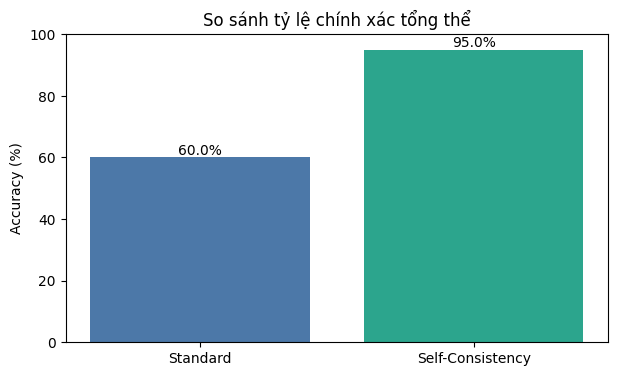

In [4]:
total_samples = len(df)
std_acc = df["std_correct"].mean() * 100
sc_acc = df["sc_correct"].mean() * 100
delta_acc = sc_acc - std_acc
avg_consistency = df["consistency"].mean()

summary_df = pd.DataFrame({
    "Metric": [
        "Accuracy STD (%)",
        "Accuracy SC (%)",
        "Delta Accuracy (SC - STD)",
        "Average Consistency",
    ],
    "Value": [std_acc, sc_acc, delta_acc, avg_consistency],
})

display(summary_df)
print(f"Tổng số mẫu: {total_samples}")
print(f"Accuracy Standard: {std_acc:.2f}%")
print(f"Accuracy Self-Consistency: {sc_acc:.2f}%")
print(f"Delta Accuracy: {delta_acc:.2f}%")
print(f"Average Consistency: {avg_consistency:.3f}")

plt.figure(figsize=(7, 4))
plt.bar(["Standard", "Self-Consistency"], [std_acc, sc_acc], color=["#4C78A8", "#2CA58D"])
plt.ylabel("Accuracy (%)")
plt.title("So sánh tỷ lệ chính xác tổng thể")
plt.ylim(0, 100)
for idx, value in enumerate([std_acc, sc_acc]):
    plt.text(idx, value + 1, f"{value:.1f}%", ha="center")
plt.show()


### 3.2. Mối tương quan giữa Consistency và Correctness

Ở đây ta chia các câu trả lời self-consistency theo dải điểm nhất quán:
- `0.0 - 0.5`
- `0.5 - 0.8`
- `0.8 - 1.0`

Sau đó, với mỗi dải, ta tính tỷ lệ `sc_correct`. Kỳ vọng là dải có consistency càng cao thì accuracy cũng càng cao.

Nếu xuất hiện các case có `consistency` rất cao nhưng `sc_correct = 0`, đó là dấu hiệu mô hình đang **tự tin sai** thay vì chỉ ngẫu nhiên dao động.


,consistency_bin,num_samples,sc_accuracy,avg_consistency
0,0.0-0.5,0,NaN,NaN
1,0.5-0.8,0,NaN,NaN
2,0.8-1.0,20,95.0,0.978


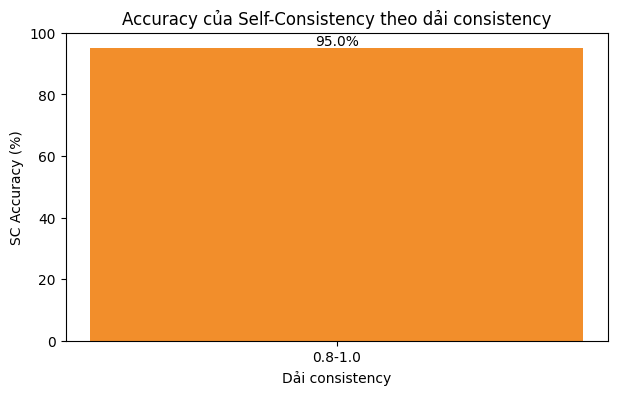

Các case consistency cao nhưng vẫn sai:


,id,ground_truth,std_ans,sc_ans,std_correct,sc_correct,consistency,consistency_bin
0,1,2280,2180.0,2180,0,0,0.97,0.8-1.0


In [5]:
bin_edges = [0.0, 0.5, 0.8, 1.01]
bin_labels = ["0.0-0.5", "0.5-0.8", "0.8-1.0"]

analysis_df = df.copy()
analysis_df["consistency_bin"] = pd.cut(
    analysis_df["consistency"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
    right=False,
)

bin_summary = (
    analysis_df.groupby("consistency_bin", observed=False)
    .agg(
        num_samples=("id", "count"),
        sc_accuracy=("sc_correct", "mean"),
        avg_consistency=("consistency", "mean"),
    )
    .reset_index()
)
bin_summary["sc_accuracy"] = bin_summary["sc_accuracy"] * 100

display(bin_summary)

plt.figure(figsize=(7, 4))
plt.bar(bin_summary["consistency_bin"].astype(str), bin_summary["sc_accuracy"], color="#F28E2B")
plt.xlabel("Dải consistency")
plt.ylabel("SC Accuracy (%)")
plt.title("Accuracy của Self-Consistency theo dải consistency")
plt.ylim(0, 100)
for idx, value in enumerate(bin_summary["sc_accuracy"]):
    if pd.notna(value):
        plt.text(idx, value + 1, f"{value:.1f}%", ha="center")
plt.show()

high_confidence_wrong = analysis_df[(analysis_df["consistency"] >= 0.9) & (analysis_df["sc_correct"] == 0)]
print("Các case consistency cao nhưng vẫn sai:")
display(high_confidence_wrong if not high_confidence_wrong.empty else pd.DataFrame({"message": ["Không có case nào"]}))


### 3.3. Phân rã các nhóm case quan trọng

Phần này tách kết quả thành các nhóm để đọc hành vi của mô hình rõ hơn:
- **STD sai nhưng SC đúng**: dấu hiệu self-consistency tự sửa lỗi thành công
- **STD đúng nhưng SC sai**: rủi ro do nhiễu từ temperature cao hoặc voting chọn sai hướng
- **Cả hai đều sai**: những câu hỏi khó hoặc vượt quá khả năng suy luận hiện tại

Đây là phần rất hữu ích khi viết nhận xét thực nghiệm, vì nó cho thấy self-consistency không chỉ tăng hay giảm accuracy, mà còn thay đổi *loại lỗi* nào.


In [6]:
std_wrong_sc_right = df[(df["std_correct"] == 0) & (df["sc_correct"] == 1)]
std_right_sc_wrong = df[(df["std_correct"] == 1) & (df["sc_correct"] == 0)]
both_wrong = df[(df["std_correct"] == 0) & (df["sc_correct"] == 0)]
both_right = df[(df["std_correct"] == 1) & (df["sc_correct"] == 1)]

case_summary = pd.DataFrame({
    "Case": [
        "STD sai, SC đúng",
        "STD đúng, SC sai",
        "Cả hai đều sai",
        "Cả hai đều đúng",
    ],
    "Count": [
        len(std_wrong_sc_right),
        len(std_right_sc_wrong),
        len(both_wrong),
        len(both_right),
    ],
})

display(case_summary)
print("ID các câu STD sai nhưng SC đúng:", std_wrong_sc_right["id"].tolist())
print("ID các câu STD đúng nhưng SC sai:", std_right_sc_wrong["id"].tolist())
print("ID các câu cả hai đều sai:", both_wrong["id"].tolist())


,Case,Count
0,"STD sai, SC đúng",7
1,"STD đúng, SC sai",0
2,Cả hai đều sai,1
3,Cả hai đều đúng,12


ID các câu STD sai nhưng SC đúng: [3, 4, 7, 8, 12, 15, 17]
ID các câu STD đúng nhưng SC sai: []
ID các câu cả hai đều sai: [1]
